# Curso 2, Semana 1 — Regularización L2 y Dropout
### Kevin Vargas Flores

En esta práctica se conserva la nomenclatura de la red profunda anterior: ejemplos por columnas, parámetros `W1`, `b1`, ..., cachés por capa, ReLU en las capas ocultas y sigmoide en la salida.

## Objetivos

1. Reconocer el sobreajuste mediante la brecha entrenamiento–validación.
2. Implementar regularización L2 en el costo y en los gradientes.
3. Implementar dropout invertido en propagación hacia adelante y hacia atrás.
4. Transferir el procedimiento a otro conjunto de datos y otra arquitectura.

> Una regularización adecuada puede reducir la exactitud de entrenamiento y, al mismo tiempo, mejorar la generalización.


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

SEED = 42
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})


## Ejercicio 1. Comparación controlada con `make_moons`

Se utilizará una red deliberadamente amplia y pocos ejemplos de entrenamiento para hacer visible el sobreajuste. Los conjuntos de validación y prueba no participan en el aprendizaje de los parámetros.


train: (2, 270) dev: (2, 315) test: (2, 315)


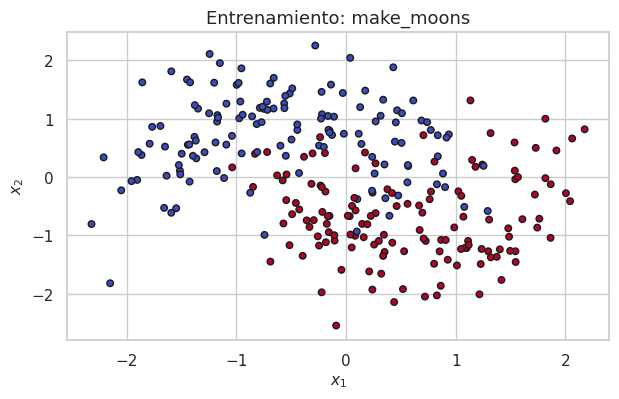

In [68]:
def prepare_data(X_raw, y_raw, train_size=0.30, seed=SEED):
    X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
        X_raw, y_raw, train_size=train_size, stratify=y_raw, random_state=seed
    )
    X_dev_raw, X_test_raw, y_dev_raw, y_test_raw = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
    )

    # La normalización se calcula únicamente con entrenamiento.
    mu = X_train_raw.mean(axis=0, keepdims=True)
    sigma = X_train_raw.std(axis=0, keepdims=True)

    def transform(X, y):
        return ((X - mu) / sigma).T, y.reshape(1, -1)

    return (*transform(X_train_raw, y_train_raw),
            *transform(X_dev_raw, y_dev_raw),
            *transform(X_test_raw, y_test_raw))


X_raw, y_raw = make_moons(n_samples=900, noise=0.32, random_state=SEED)
X_train, Y_train, X_dev, Y_dev, X_test, Y_test = prepare_data(X_raw, y_raw)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)
plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=22)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Entrenamiento: make_moons")
plt.show()


### Regularización L2

L2 modifica el objetivo y el gradiente:

$$J_{L2}=J_{datos}+\frac{\lambda}{2m}\sum_{l=1}^{L}\|W^{[l]}\|_F^2,$$

$$dW^{[l]}=dW_{backprop}^{[l]}+\frac{\lambda}{m}W^{[l]}.$$

No se regularizan los sesgos.

### Dropout invertido

En cada capa oculta:

$$D^{[l]}\sim\operatorname{Bernoulli}(keep\_prob),$$

$$\widetilde A^{[l]}=\frac{A^{[l]}\odot D^{[l]}}{keep\_prob}.$$

En el backward se reutiliza exactamente la misma máscara. Dropout se desactiva durante validación, prueba y predicción.


In [69]:
def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))


def binary_cross_entropy(AL, Y):
    AL = np.clip(AL, 1e-12, 1 - 1e-12)
    return float(-np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL)))


def initialize_he(layer_dims, seed=SEED):
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        n_out, n_in = layer_dims[l], layer_dims[l - 1]
        params[f"W{l}"] = rng.standard_normal((n_out, n_in)) * np.sqrt(2 / n_in)
        params[f"b{l}"] = np.zeros((n_out, 1))
    return params


## Implementación de L2 y dropout


In [70]:
def l2_penalty(params, m, lambd):
    weights = (value for key, value in params.items() if key.startswith("W"))
    return lambd * sum(np.sum(W**2) for W in weights) / (2 * m)


def L_model_forward(X, params, keep_prob=1.0, training=False, rng=None):
    if not 0 < keep_prob <= 1:
        raise ValueError("keep_prob debe pertenecer a (0, 1]")
    if rng is None:
        rng = np.random.default_rng(SEED)

    A, caches = X, []
    L = len(params) // 2

    for l in range(1, L):
        A_prev = A
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = W @ A_prev + b
        A = np.maximum(0, Z)

        D = None
        if training and keep_prob < 1:
            D = rng.random(A.shape) < keep_prob
            A = A * D / keep_prob

        caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": D})

    A_prev = A
    W, b = params[f"W{L}"], params[f"b{L}"]
    Z = W @ A_prev + b
    AL = sigmoid(Z)
    caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": None})
    return AL, caches


def L_model_backward(AL, Y, caches, lambd=0.0, keep_prob=1.0):
    grads = {}
    m, L = Y.shape[1], len(caches)

    cache = caches[-1]
    dZ = AL - Y

    grads[f"dW{L}"] = (dZ @ cache["A_prev"].T / m
                        + lambd * cache["W"] / m)
    grads[f"db{L}"] = np.sum(dZ, axis=1, keepdims=True) / m
    dA = cache["W"].T @ dZ

    for l in reversed(range(1, L)):
        cache = caches[l - 1]

        if cache["D"] is not None:
            dA = dA * cache["D"] / keep_prob

        dZ = dA * (cache["Z"] > 0)
        grads[f"dW{l}"] = (dZ @ cache["A_prev"].T / m
                            + lambd * cache["W"] / m)
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
        dA = cache["W"].T @ dZ

    return grads


In [71]:
def update_parameters_deep(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params


def predict_deep(params, X):
    AL, _ = L_model_forward(X, params, training=False)
    return (AL >= 0.5).astype(int)


def accuracy(params, X, Y):
    return 100 * np.mean(predict_deep(params, X) == Y)


def total_weight_norm(params):
    return np.sqrt(sum(np.sum(value**2)
                       for key, value in params.items()
                       if key.startswith("W")))


def train_regularized(X_train, Y_train, layer_dims, lambd=0.0,
                      keep_prob=1.0, iterations=6500,
                      learning_rate=0.03, seed=SEED):
    params = initialize_he(layer_dims, seed)
    rng = np.random.default_rng(seed)
    history = {"data_loss": [], "objective": []}

    for i in range(iterations):
        AL, caches = L_model_forward(
            X_train, params, keep_prob=keep_prob,
            training=(keep_prob < 1), rng=rng
        )
        data_loss = binary_cross_entropy(AL, Y_train)
        objective = data_loss + l2_penalty(params, Y_train.shape[1], lambd)
        grads = L_model_backward(
            AL, Y_train, caches, lambd=lambd, keep_prob=keep_prob
        )
        params = update_parameters_deep(params, grads, learning_rate)

        if i % 100 == 0:
            history["data_loss"].append(data_loss)
            history["objective"].append(objective)

    return params, history


### Experimento controlado

Solo cambia la técnica de regularización. Se mantienen fijos los datos, la arquitectura, la inicialización, la tasa de aprendizaje y el número de iteraciones.


Sin regularización train= 93.33%  dev= 87.94%  brecha= 5.40 pp  ||W||= 15.02
L2                 train= 90.74%  dev= 90.16%  brecha= 0.58 pp  ||W||=  6.78
Dropout            train= 92.22%  dev= 88.57%  brecha= 3.65 pp  ||W||= 14.20


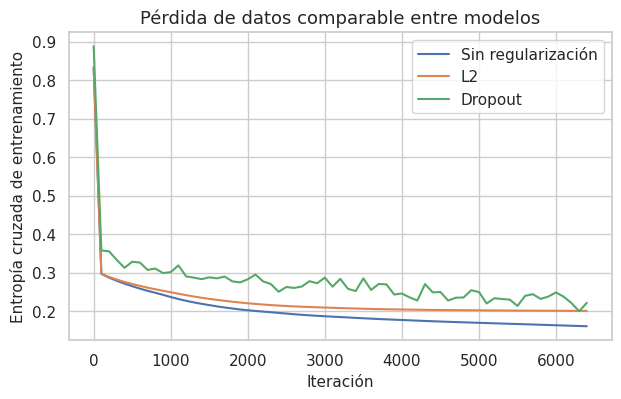

In [72]:
layer_dims = [2, 60, 40, 20, 1]
settings = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 1.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.80},
}

models, histories = {}, {}

for name, cfg in settings.items():
    models[name], histories[name] = train_regularized(
        X_train, Y_train, layer_dims, **cfg
    )

    train_acc = accuracy(models[name], X_train, Y_train)
    dev_acc = accuracy(models[name], X_dev, Y_dev)
    print(f"{name:18s} train={train_acc:6.2f}%  dev={dev_acc:6.2f}%  "
          f"brecha={train_acc-dev_acc:5.2f} pp  "
          f"||W||={total_weight_norm(models[name]):6.2f}")

for name, history in histories.items():
    steps = np.arange(len(history["data_loss"])) * 100
    plt.plot(steps, history["data_loss"], label=name)

plt.xlabel("Iteración")
plt.ylabel("Entropía cruzada de entrenamiento")
plt.title("Pérdida de datos comparable entre modelos")
plt.legend()
plt.show()


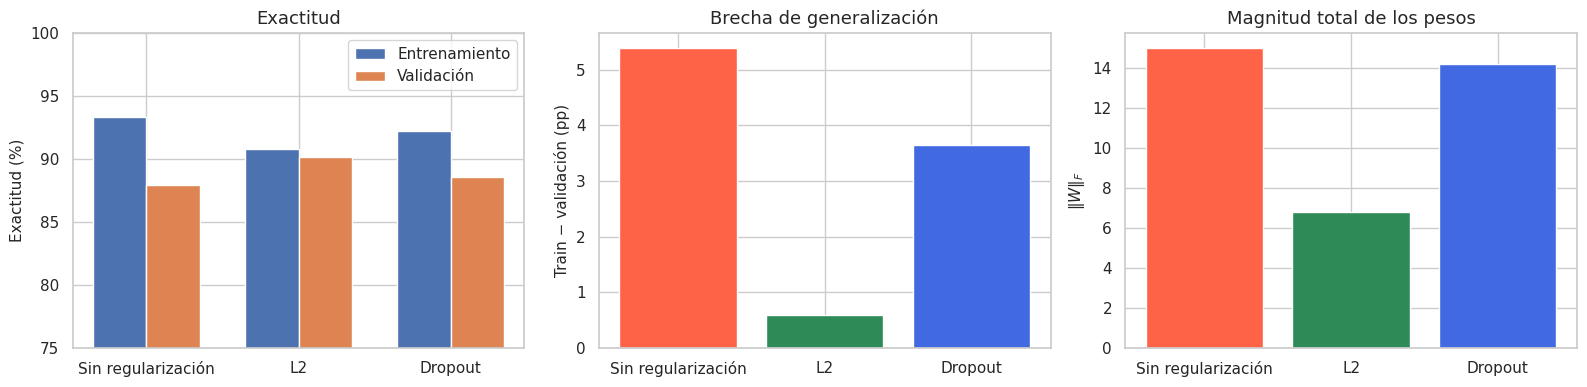

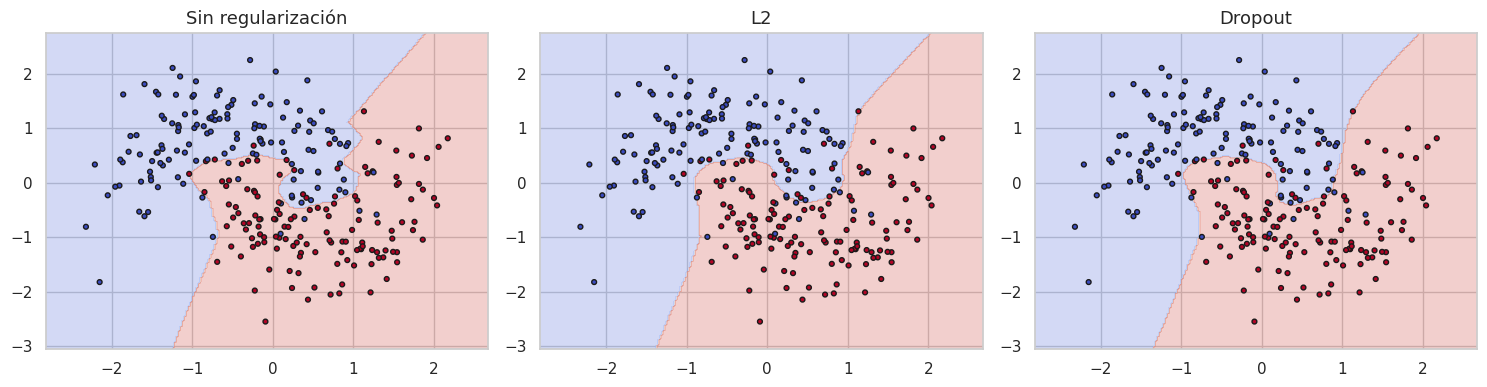

In [73]:
names = list(models)
train_scores = [accuracy(models[n], X_train, Y_train) for n in names]
dev_scores = [accuracy(models[n], X_dev, Y_dev) for n in names]
gaps = [train_scores[i] - dev_scores[i] for i in range(len(names))]
weight_norms = [total_weight_norm(models[n]) for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(names)); width = 0.35

axes[0].bar(x-width/2, train_scores, width, label="Entrenamiento")
axes[0].bar(x+width/2, dev_scores, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(75, 100)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x1 = np.linspace(X_train[0].min()-0.5, X_train[0].max()+0.5, 220)
x2 = np.linspace(X_train[1].min()-0.5, X_train[1].max()+0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    zz = predict_deep(params, grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
               cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(name)

plt.tight_layout(); plt.show()


### Selección y evaluación final

El conjunto de prueba se consulta una sola vez, después de seleccionar el modelo con validación.


In [74]:
best_name = max(models, key=lambda name: accuracy(models[name], X_dev, Y_dev))
best_model = models[best_name]
print("Modelo seleccionado con validación:", best_name)
print(f"Exactitud final en prueba: {accuracy(best_model, X_test, Y_test):.2f}%")


Modelo seleccionado con validación: L2
Exactitud final en prueba: 88.89%


### Preguntas de análisis

1. ¿Qué evidencia indica que el modelo sin regularización presenta sobreajuste?

Tres cosas:
  
- La diferencia que se encuentra entre el modelo de entrenamiento y el modelo de desarrollo o prueba. Esta de 5.40, la diferencia más alta de los 3 modelos.

- Frontera de decisión compleja, ya que la del modelo sin normalizar se mira como que quisiera adaptarse para separar todos los puntos segun su distribución
  
- La norma de los pesos es muy grande 15.02, esto nos dice que el modelo reacciona de manera exagerada a los valores de entrada

2. ¿Por qué L2 reduce la norma $\Vert W\Vert_F$?

Para minimizar el costo total, el algoritmo de optimización no solo debe reducir el error de clasificación, sino también mantener los pesos lo más cercanos a cero posible.

3. ¿Por qué dropout se desactiva durante validación y prueba?

Porque este algoritmo o paradigma se utiliza unicamente cuando se esta entrenando el modelo ya que a la "hora de la verdad" tendriamos que realmente utilizar todas las neuronas que tengamos disponibles, que aproveche el poder de la red completa con todas sus conexiones aprendidas.

4. ¿Por qué una exactitud de entrenamiento menor no implica necesariamente un peor modelo?

Lo que se busca es que el modelo pueda generalizar y NO memorizar, es por ello que el error es normal, incluso en humanos este error debe de existir este sesgo que nos permita fallar.

## Ejercicio 2. Transferencia a `make_circles`

Ahora se utiliza otro conjunto de datos y una arquitectura diferente. La selección de hiperparámetros debe hacerse con validación; prueba se utiliza únicamente al final.


train: (2, 90) dev: (2, 255) test: (2, 255)


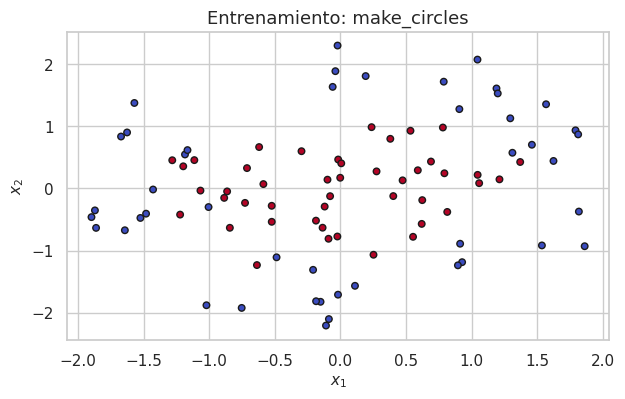

In [75]:
X_raw, y_raw = make_circles(
    n_samples=600, noise=0.18, factor=0.45, random_state=SEED
)

X_train, Y_train, X_dev, Y_dev, X_test, Y_test = prepare_data(
    X_raw, y_raw, train_size=0.15
)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)
plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=22)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Entrenamiento: make_circles")
plt.show()


Sin regularización train= 98.89%  dev= 83.92%  brecha=14.97 pp  ||W||= 15.15
L2                 train= 94.44%  dev= 90.20%  brecha= 4.25 pp  ||W||=  4.47
Dropout            train= 96.67%  dev= 85.88%  brecha=10.78 pp  ||W||= 14.24


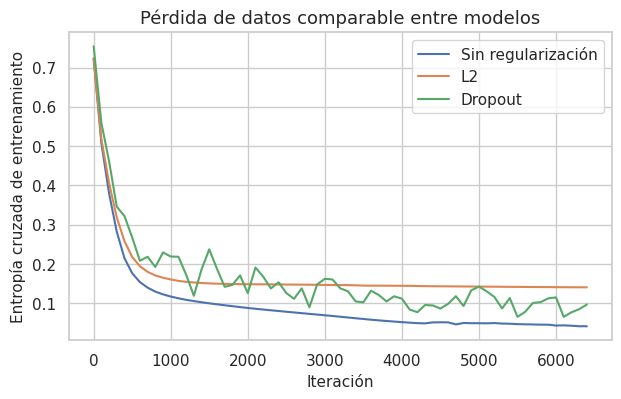

In [76]:
# Segunda arquitectura: distinta de la utilizada con make_moons.
layer_dims = [2, 64, 32, 16, 1]

# Configuraciones seleccionadas usando únicamente validación.
settings = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 1.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.90},
}

models, histories = {}, {}

for name, cfg in settings.items():
    models[name], histories[name] = train_regularized(
        X_train, Y_train, layer_dims, **cfg
    )

    train_acc = accuracy(models[name], X_train, Y_train)
    dev_acc = accuracy(models[name], X_dev, Y_dev)
    print(f"{name:18s} train={train_acc:6.2f}%  dev={dev_acc:6.2f}%  "
          f"brecha={train_acc-dev_acc:5.2f} pp  "
          f"||W||={total_weight_norm(models[name]):6.2f}")

for name, history in histories.items():
    steps = np.arange(len(history["data_loss"])) * 100
    plt.plot(steps, history["data_loss"], label=name)

plt.xlabel("Iteración")
plt.ylabel("Entropía cruzada de entrenamiento")
plt.title("Pérdida de datos comparable entre modelos")
plt.legend()
plt.show()


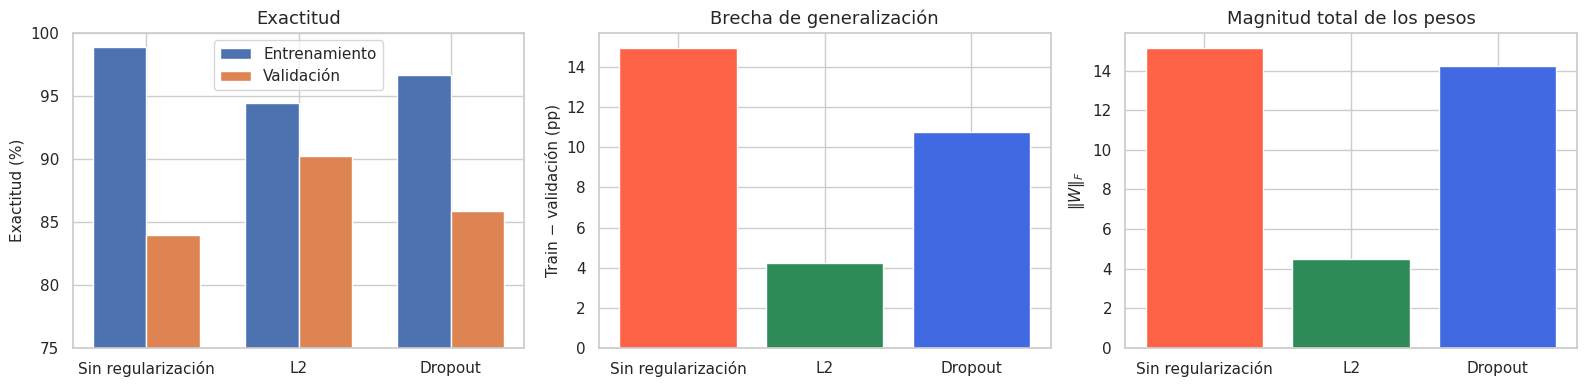

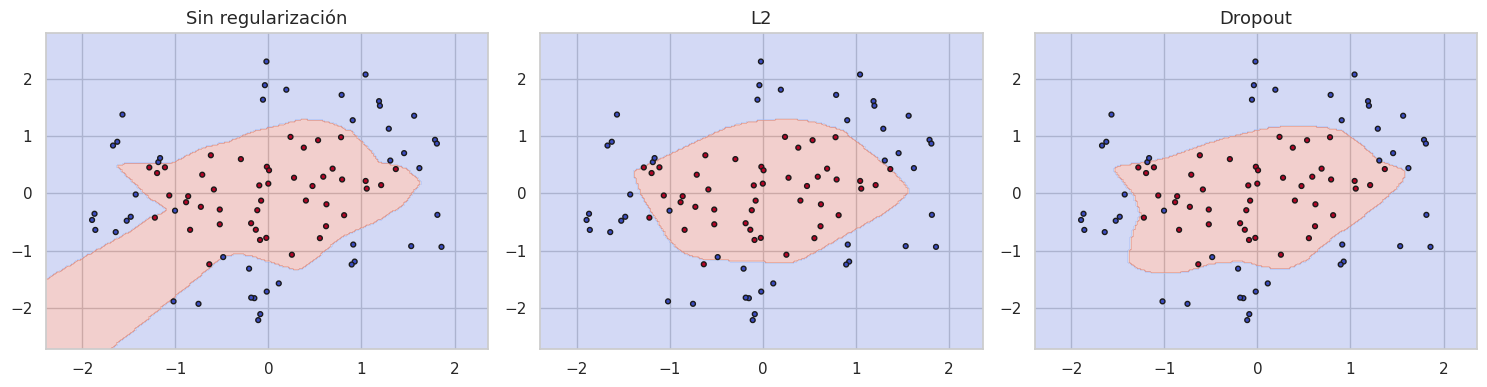

In [77]:
names = list(models)
train_scores = [accuracy(models[n], X_train, Y_train) for n in names]
dev_scores = [accuracy(models[n], X_dev, Y_dev) for n in names]
gaps = [train_scores[i] - dev_scores[i] for i in range(len(names))]
weight_norms = [total_weight_norm(models[n]) for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(names)); width = 0.35

axes[0].bar(x-width/2, train_scores, width, label="Entrenamiento")
axes[0].bar(x+width/2, dev_scores, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(75, 100)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x1 = np.linspace(X_train[0].min()-0.5, X_train[0].max()+0.5, 220)
x2 = np.linspace(X_train[1].min()-0.5, X_train[1].max()+0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    zz = predict_deep(params, grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
               cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(name)

plt.tight_layout(); plt.show()


In [78]:
best_name = max(models, key=lambda name: accuracy(models[name], X_dev, Y_dev))
best_model = models[best_name]
print("Modelo seleccionado con validación:", best_name)
print(f"Exactitud final en prueba: {accuracy(best_model, X_test, Y_test):.2f}%")


Modelo seleccionado con validación: L2
Exactitud final en prueba: 91.76%


### Conclusiones

- El modelo sin regularización funciona como línea base.
- L2 controla directamente la magnitud de los pesos.
- Dropout entrena subredes distintas y reduce la dependencia entre neuronas.
- El mejor modelo se decide por validación, no por la exactitud de entrenamiento ni por prueba.


# Práctica integral de evaluación: regularización aplicada a un conjunto de datos real para la clasificación binaria.

El propósito principal no es solamente obtener una exactitud elevada, sino construir, identificar y explicar correctamente el **pipeline completo de aprendizaje profundo** que hemos estudiado.

## Actividades

1. Describir el dataset, sus variables, clases, distribución y posibles valores faltantes.
2. Dividir los datos de forma estratificada en entrenamiento, validación y prueba.
3. Calcular la media y desviación estándar únicamente con entrenamiento y utilizarlas para normalizar los tres conjuntos.
4. Comparar al menos tres arquitecturas:

| Arquitectura | Capas |
|---|---|
| Pequeña | `[n_x,16,8,1]` |
| Mediana | `[n_x,64,32,16,1]` |
| Amplia | `[n_x,128,64,32,1]` |

5. Utilizar inicialización He, ReLU en las capas ocultas, sigmoide en la salida y entropía cruzada binaria.
6. Entrenar y comparar:
   - modelo sin regularización;
   - modelo con L2;
   - modelo con dropout.
7. Seleccionar `lambda` y `keep_prob` utilizando únicamente validación.
8. Evaluar una sola vez en prueba el modelo seleccionado.
9. Identificar y explicar en el código:
   - normalización sin fuga de información;
   - inicialización He;
   - penalización L2 en el costo;
   - contribución de L2 en los gradientes;
   - dropout en forward y backward;
   - desactivación de dropout durante validación y prueba.

## Resultados

Presentar una tabla comparativa:

| Arquitectura | Método | Hiperparámetro | Train | Validación | Brecha | $\Vert W\Vert_F$ |
|---|---|---:|---:|---:|---:|---:|
|  | Sin regularización | — |  |  |  |  |
|  | L2 | $\lambda=$ |  |  |  |  |
|  | Dropout | `keep_prob=` |  |  |  |  |

También deberán presentar:

- curvas de pérdida;
- matriz de confusión;
- exactitud, precisión, recall y F1;
- configuración seleccionada y resultado final en prueba.

## Pregunta integradora

> ¿Qué arquitectura y método de regularización ofrecen la mejor capacidad de generalización y qué resultados respaldan esta conclusión?

No será suficiente ejecutar el código. Durante la exposición, el estudiante deberá identificar y explicar cada etapa del pipeline.

## 0. Importación del Dataset

In [79]:

"No encontre un dataset de mi interes e intente hacerlo con un dataset propio"
!git clone https://github.com/kao05/Deep-Learning
import os
archivos_data = os.listdir('Deep-Learning/Data')
print("Archivos en la carpeta data:", archivos_data)
df = pd.read_csv('Deep-Learning/Data/Churn.csv')


fatal: destination path 'Deep-Learning' already exists and is not an empty directory.
Archivos en la carpeta data: ['Churn.csv', 'README.md']


In [80]:
#Librerias y primera visualizacion del dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(df.shape)
df.info()
df.head()


(10000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 1. Descripción del dataset

 1. INFORMACIÓN GENERAL Y VALORES FALTANTES
Total de Filas (Clientes): 10000
Total de Columnas:         18

Conteo de Valores Nulos por Columna:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

 2. ESTADÍSTICA DESCRIPTIVA (VARIABLES NUMÉRICAS)


,count,mean,std,min,50%,max
CreditScore,10000.0,650.528800,96.653299,350.00,652.000,850.00
Age,10000.0,38.921800,10.487806,18.00,37.000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,5.000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,97198.540,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,1.000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,1.000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,100193.915,199992.48
Exited,10000.0,0.203800,0.402842,0.00,0.000,1.00
Complain,10000.0,0.204400,0.403283,0.00,0.000,1.00



 3. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Exited)


,Total Clientes,Porcentaje (%)
Exited,,
0,7962,79.62
1,2038,20.38


/tmp/ipykernel_2677/2606078428.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', palette='Set2', ax=axes[0, 0])
/tmp/ipykernel_2677/2606078428.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Age', palette='Set2', ax=axes[0, 1])
/tmp/ipykernel_2677/2606078428.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Balance', palette='Set2', ax=axes[1, 0])


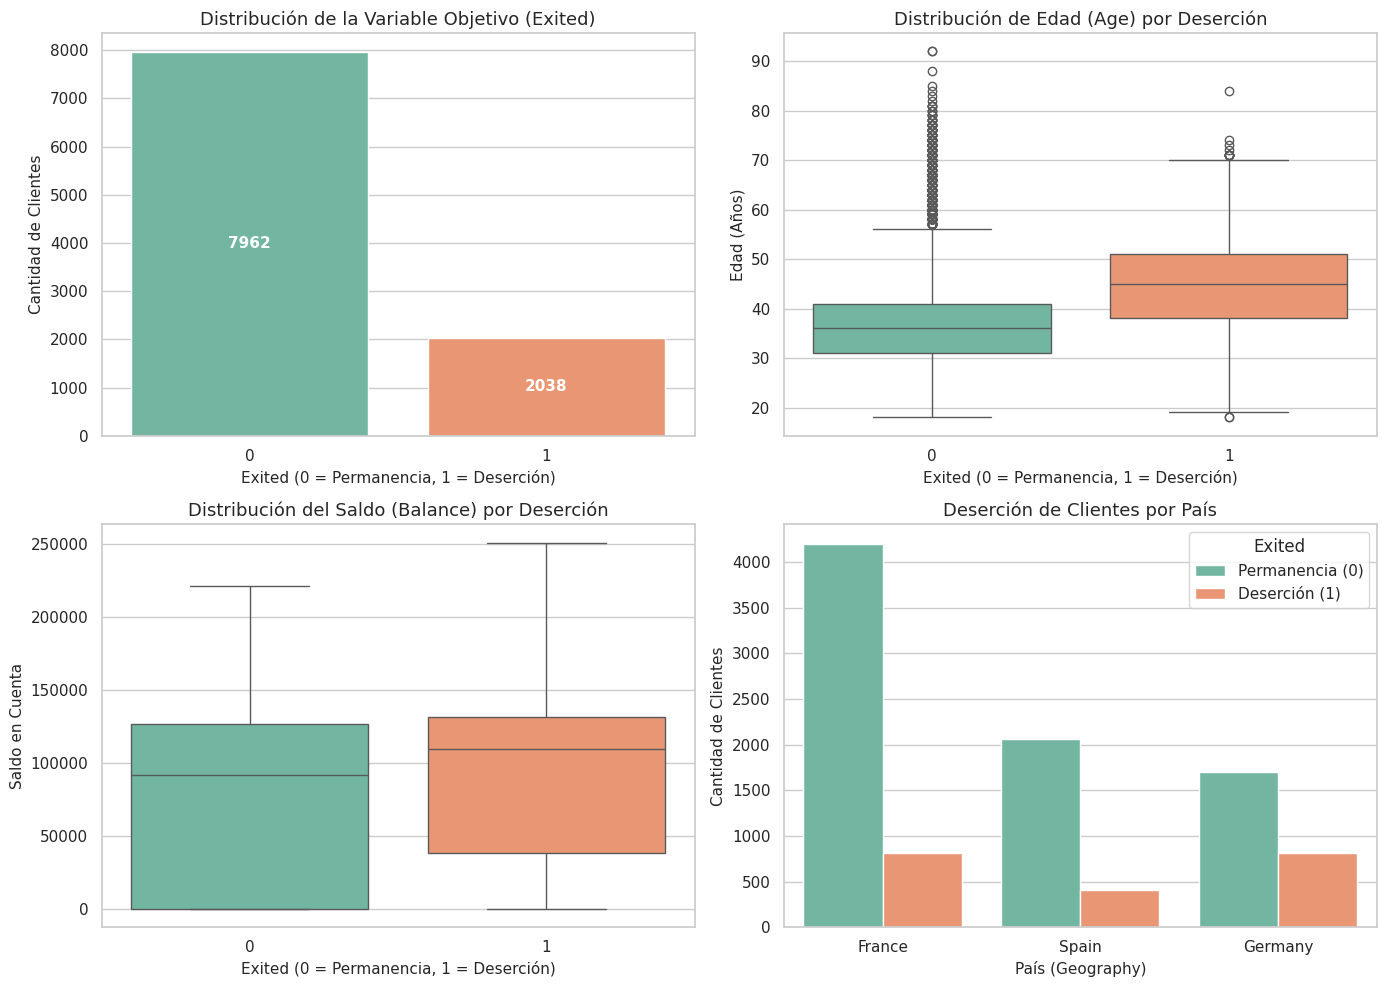

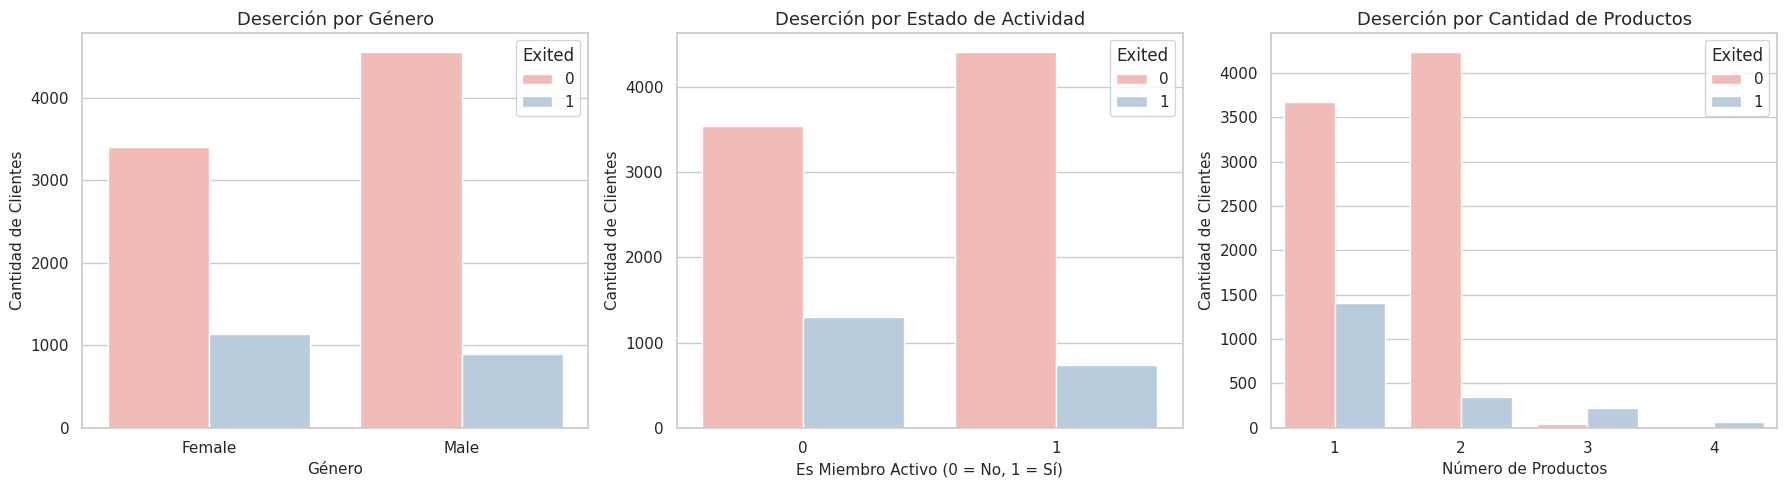

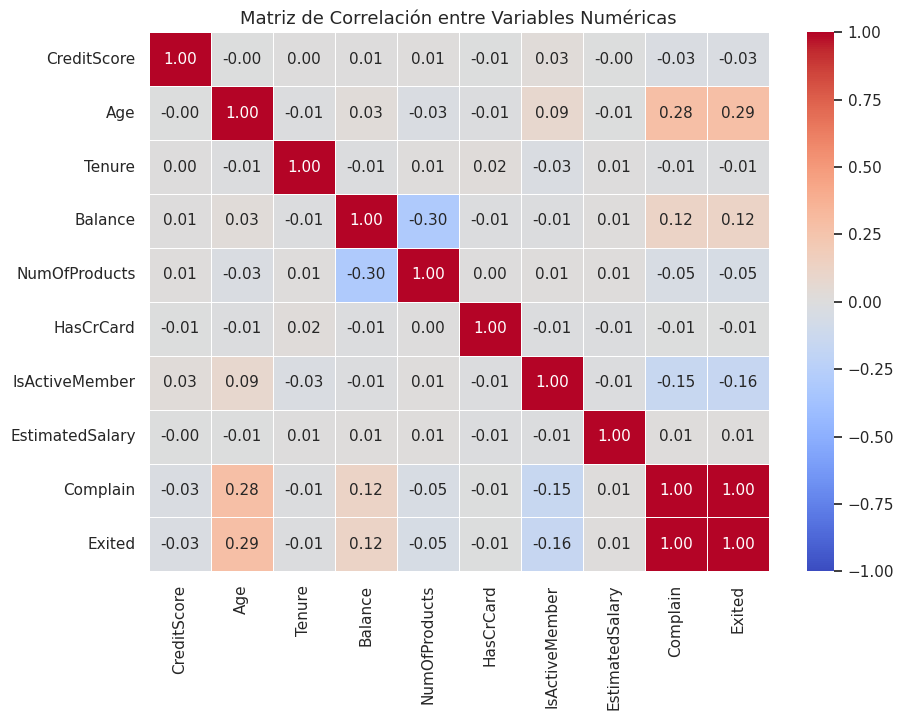

In [81]:
# Configuración visual para Jupyter Notebook
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
# 2. VERIFICACIÓN DE ESTRUCTURA Y VALORES FALTANTES
print("==================================================")
print(" 1. INFORMACIÓN GENERAL Y VALORES FALTANTES")
print("==================================================")
print(f"Total de Filas (Clientes): {df.shape[0]}")
print(f"Total de Columnas:         {df.shape[1]}")
print("\nConteo de Valores Nulos por Columna:")
print(df.isnull().sum())

# 3. RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS
print("\n==================================================")
print(" 2. ESTADÍSTICA DESCRIPTIVA (VARIABLES NUMÉRICAS)")
print("==================================================")
cols_a_describir = [c for c in df.columns if c not in ['RowNumber', 'CustomerId', 'Surname']]
display(df[cols_a_describir].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# 4. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
print("\n==================================================")
print(" 3. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Exited)")
print("==================================================")
conteo_exited = df['Exited'].value_counts()
pct_exited = df['Exited'].value_counts(normalize=True) * 100
df_exited_summary = pd.DataFrame({'Total Clientes': conteo_exited, 'Porcentaje (%)': pct_exited})
display(df_exited_summary)


# ==============================================================================
# FASE 2: PANELES DE VISUALIZACIÓN GRÁFICA
# ==============================================================================

# --- PANEL 1: VARIABLES CLAVE VS DESERCIÓN ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Variable Objetivo
sns.countplot(data=df, x='Exited', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de la Variable Objetivo (Exited)')
axes[0, 0].set_xlabel('Exited (0 = Permanencia, 1 = Deserción)')
axes[0, 0].set_ylabel('Cantidad de Clientes')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Subplot 2: Edad vs Deserción
sns.boxplot(data=df, x='Exited', y='Age', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Edad (Age) por Deserción')
axes[0, 1].set_xlabel('Exited (0 = Permanencia, 1 = Deserción)')
axes[0, 1].set_ylabel('Edad (Años)')

# Subplot 3: Saldo Bancario vs Deserción
sns.boxplot(data=df, x='Exited', y='Balance', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Distribución del Saldo (Balance) por Deserción')
axes[1, 0].set_xlabel('Exited (0 = Permanencia, 1 = Deserción)')
axes[1, 0].set_ylabel('Saldo en Cuenta')

# Subplot 4: Geografía vs Deserción
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Deserción de Clientes por País')
axes[1, 1].set_xlabel('País (Geography)')
axes[1, 1].set_ylabel('Cantidad de Clientes')
axes[1, 1].legend(title='Exited', labels=['Permanencia (0)', 'Deserción (1)'])

plt.tight_layout()
plt.show()

# --- PANEL 2: VARIABLES CATEGÓRICAS Y COMPORTAMIENTO ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Género vs Deserción
sns.countplot(data=df, x='Gender', hue='Exited', palette='Pastel1', ax=axes[0])
axes[0].set_title('Deserción por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de Clientes')

# Subplot 2: Miembro Activo vs Deserción
sns.countplot(data=df, x='IsActiveMember', hue='Exited', palette='Pastel1', ax=axes[1])
axes[1].set_title('Deserción por Estado de Actividad')
axes[1].set_xlabel('Es Miembro Activo (0 = No, 1 = Sí)')
axes[1].set_ylabel('Cantidad de Clientes')

# Subplot 3: Número de Productos vs Deserción
sns.countplot(data=df, x='NumOfProducts', hue='Exited', palette='Pastel1', ax=axes[2])
axes[2].set_title('Deserción por Cantidad de Productos')
axes[2].set_xlabel('Número de Productos')
axes[2].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

# --- PANEL 3: MATRIZ DE CORRELACIÓN DE PEARSON ---
plt.figure(figsize=(10, 7))
cols_corr = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Exited']
matriz_corr = df[cols_corr].corr()

sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

## 2. Entrenamiento, validación y prueba


In [90]:
# Eliminamos identificadores usando errors='ignore' para evitar KeyError
cols_a_eliminar = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=cols_a_eliminar, errors='ignore')

# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
df_encoded = pd.get_dummies(
    df_clean,
    columns=['Geography', 'Gender', 'Card Type'],
    drop_first=True,
    dtype=float
)

# Separación en Matriz X y Vector Y
X_matrix = df_encoded.drop(columns=['Exited']).values # Forma: (10000, n_x)
Y_vector = df_encoded['Exited'].values                # Forma: (10000,)

# 3. FUNCIÓN DE DIVISIÓN ESTRATIFICADA EN NUMPY PURO
def stratified_split_numpy(X, Y, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, seed=42):
    np.random.seed(seed)
    classes = np.unique(Y)

    train_idx, dev_idx, test_idx = [], [], []

    for c in classes:
        cls_indices = np.where(Y == c)[0]
        np.random.shuffle(cls_indices)

        n_total = len(cls_indices)
        n_train = int(n_total * train_ratio)
        n_dev = int(n_total * dev_ratio)

        train_idx.extend(cls_indices[:n_train])
        dev_idx.extend(cls_indices[n_train : n_train + n_dev])
        test_idx.extend(cls_indices[n_train + n_dev :])

    np.random.shuffle(train_idx)
    np.random.shuffle(dev_idx)
    np.random.shuffle(test_idx)

    return X[train_idx], Y[train_idx], X[dev_idx], Y[dev_idx], X[test_idx], Y[test_idx]

# Ejecución de la división estratificada
X_train_raw, Y_train_raw, X_dev_raw, Y_dev_raw, X_test_raw, Y_test_raw = stratified_split_numpy(
    X_matrix, Y_vector, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, seed=42
)

# 4. VERIFICACIÓN
print("==================================================")
print(" RESULTADOS DE LA DIVISIÓN ESTRATIFICADA")
print("==================================================")
print(f"Número de características de entrada (n_x): {X_matrix.shape[1]}")
print(f"Ejemplos Train: {X_train_raw.shape[0]} (~60%)")
print(f"Ejemplos Dev:   {X_dev_raw.shape[0]} (~20%)")
print(f"Ejemplos Test:  {X_test_raw.shape[0]} (~20%)")

print("\nProporción de Deserción (Exited = 1):")
print(f"Train: {(Y_train_raw == 1).mean() * 100:.2f}%")
print(f"Dev:   {(Y_dev_raw == 1).mean() * 100:.2f}%")
print(f"Test:  {(Y_test_raw == 1).mean() * 100:.2f}%")

 RESULTADOS DE LA DIVISIÓN ESTRATIFICADA
Número de características de entrada (n_x): 17
Ejemplos Train: 5999 (~60%)
Ejemplos Dev:   1999 (~20%)
Ejemplos Test:  2002 (~20%)

Proporción de Deserción (Exited = 1):
Train: 20.37%
Dev:   20.36%
Test:  20.43%


## 3. Media y desviación estándar

In [91]:
# 1. CÁLCULO DE MEDIA (mu) Y DESVIACIÓN ESTÁNDAR (sigma) ÚNICAMENTE EN TRAIN
# Usamos keepdims=True para mantener la forma (1, n_x) para el broadcasting
mu = np.mean(X_train_raw, axis=0, keepdims=True)
sigma = np.std(X_train_raw, axis=0, keepdims=True) + 1e-8  # 1e-8 evita división por cero

# 2. ESCALADO Z-SCORE DE LOS TRES CONJUNTOS
X_train_norm = (X_train_raw - mu) / sigma
X_dev_norm   = (X_dev_raw - mu) / sigma
X_test_norm  = (X_test_raw - mu) / sigma

# 3. TRANSPOSICIÓN A FORMATO DE RED NEURONAL: (n_x, m)
# n_x = número de características (17), m = número de muestras
X_train = X_train_norm.T
X_dev   = X_dev_norm.T
X_test  = X_test_norm.T

# Ajustamos los vectores de etiquetas Y a matrices fila de forma (1, m)
Y_train = Y_train_raw.reshape(1, -1)
Y_dev   = Y_dev_raw.reshape(1, -1)
Y_test  = Y_test_raw.reshape(1, -1)

# 4. VERIFICACIÓN Y COMBO DE DIMENSIONES
print("==================================================")
print(" VERIFICACIÓN DE DIMENSIONES Y NORMALIZACIÓN")
print("==================================================")
print(f"Dimensiones X_train: {X_train.shape} | Y_train: {Y_train.shape}")
print(f"Dimensiones X_dev:   {X_dev.shape}   | Y_dev:   {Y_dev.shape}")
print(f"Dimensiones X_test:  {X_test.shape}  | Y_test:  {Y_test.shape}")

print("\n--- COMPROBACIÓN ESTADÍSTICA EN TRAIN ---")
print(f"Media de características en X_train (Cercana a 0): {np.mean(X_train, axis=1)[:5]}")
print(f"Desviación Estándar en X_train     (Igual a 1):   {np.std(X_train, axis=1)[:5]}")

 VERIFICACIÓN DE DIMENSIONES Y NORMALIZACIÓN
Dimensiones X_train: (17, 5999) | Y_train: (1, 5999)
Dimensiones X_dev:   (17, 1999)   | Y_dev:   (1, 1999)
Dimensiones X_test:  (17, 2002)  | Y_test:  (1, 2002)

--- COMPROBACIÓN ESTADÍSTICA EN TRAIN ---
Media de características en X_train (Cercana a 0): [ 1.24439734e-16 -3.90678581e-17  3.11728565e-16 -3.06072887e-15
 -3.03363491e-16]
Desviación Estándar en X_train     (Igual a 1):   [1.         1.         1.         1.         0.99999998]


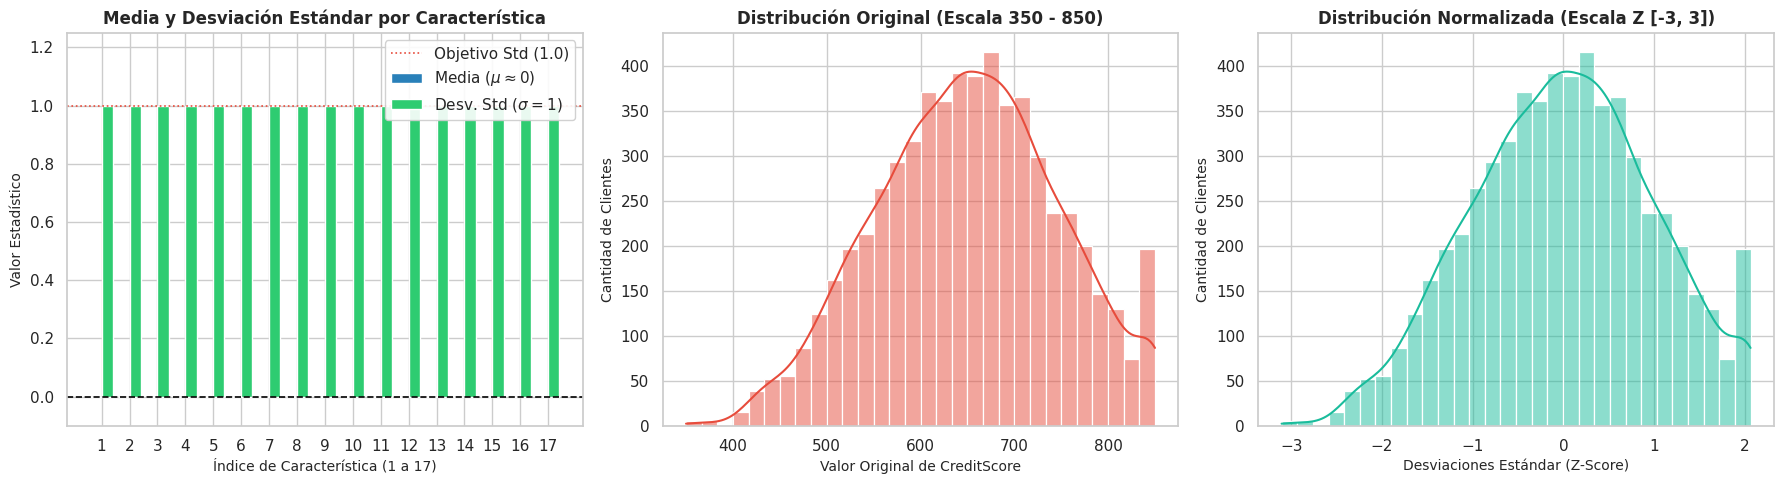

In [95]:
# Estilo general
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------------------------------------------------------------
# PANEL 1: MEDIA Y DESVIACIÓN ESTÁNDAR POR CARACTERÍSTICA (X_train)
# ------------------------------------------------------------------------------
num_features = X_train.shape[0]
feature_indices = np.arange(1, num_features + 1)

means = np.mean(X_train, axis=1)
stds = np.std(X_train, axis=1)

axes[0].bar(feature_indices - 0.2, means, width=0.4, label=r'Media ($\mu \approx 0$)', color='#2980b9')
axes[0].bar(feature_indices + 0.2, stds, width=0.4, label=r'Desv. Std ($\sigma = 1$)', color='#2ecc71')

# Líneas de referencia para evaluación presencial
axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].axhline(1, color='#e74c3c', linewidth=1.2, linestyle=':', label='Objetivo Std (1.0)')

axes[0].set_title('Media y Desviación Estándar por Característica', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Índice de Característica (1 a 17)', fontsize=10)
axes[0].set_ylabel('Valor Estadístico', fontsize=10)
axes[0].set_xticks(feature_indices)
axes[0].set_ylim(-0.10, 1.25)
axes[0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

# ------------------------------------------------------------------------------
# PANEL 2: DISTRIBUCIÓN EN ESCALA ORIGINAL (Ejemplo: CreditScore)
# ------------------------------------------------------------------------------
sns.histplot(X_train_raw[:, 0], kde=True, ax=axes[1], color='#e74c3c', bins=30)
axes[1].set_title('Distribución Original (Escala 350 - 850)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor Original de CreditScore', fontsize=10)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=10)

# ------------------------------------------------------------------------------
# PANEL 3: DISTRIBUCIÓN EN ESCALA NORMALIZADA (Z-SCORE)
# ------------------------------------------------------------------------------
sns.histplot(X_train[0, :], kde=True, ax=axes[2], color='#1abc9c', bins=30)
axes[2].set_title('Distribución Normalizada (Escala Z [-3, 3])', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Desviaciones Estándar (Z-Score)', fontsize=10)
axes[2].set_ylabel('Cantidad de Clientes', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Tres arquitecturas


##

In [96]:
# 1. DEFINICIÓN DE LAS TRES ARQUITECTURASEstudiante
# X_train.shape[0] es 17 (n_x)
n_x = X_train.shape[0]

arquitecturas = {
    "Pequeña": [n_x, 16, 8, 1],
    "Mediana": [n_x, 64, 32, 16, 1],
    "Amplia":  [n_x, 128, 64, 32, 1]
}

# 2. CONFIGURACIÓN DE EXPERIMENTOS
experimentos = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 2.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.85}
}

# Estructuras para almacenar los resultados del pipeline completo
resultados = {}
historiales_perdida = {}

print("===============================================================")
print(" INICIANDO ENTRENAMIENTO MULTI-ARQUITECTURA Y REGULARIZACIÓN")
print("===============================================================")

for aq_name, dims in arquitecturas.items():
    resultados[aq_name] = {}
    historiales_perdida[aq_name] = {}
    print(f"\n>>> Procesando Arquitectura: {aq_name} {dims}")

    for exp_name, cfg in experimentos.items():
        # Entrenamiento utilizando las funciones implementadas y probadas antes
        params, history = train_regularized(
            X_train, Y_train, layer_dims=dims,
            lambd=cfg["lambd"], keep_prob=cfg["keep_prob"],
            iterations=3000, learning_rate=0.03, seed=42
        )

        # Evaluación en Entrenamiento y Validación
        acc_train = accuracy(params, X_train, Y_train)
        acc_dev = accuracy(params, X_dev, Y_dev)
        gap = acc_train - acc_dev
        w_norm = total_weight_norm(params)

        # Guardar resultados e historial
        resultados[aq_name][exp_name] = {
            "params": params,
            "train_acc": acc_train,
            "dev_acc": acc_dev,
            "gap": gap,
            "w_norm": w_norm
        }
        historiales_perdida[aq_name][exp_name] = history

        print(f"  [{exp_name:18s}] Train: {acc_train:6.2f}% | Val: {acc_dev:6.2f}% | Brecha: {gap:5.2f} pp | ||W||_F: {w_norm:6.2f}")

print("\n===============================================================")
print(" ¡ENTRENAMIENTO COMPLETADO CON ÉXITO!")
print("===============================================================")

 INICIANDO ENTRENAMIENTO MULTI-ARQUITECTURA Y REGULARIZACIÓN

>>> Procesando Arquitectura: Pequeña [17, 16, 8, 1]
  [Sin regularización] Train:  99.83% | Val:  99.95% | Brecha: -0.12 pp | ||W||_F:   7.48
  [L2                ] Train:  99.83% | Val:  99.95% | Brecha: -0.12 pp | ||W||_F:   7.25
  [Dropout           ] Train:  99.83% | Val:  99.95% | Brecha: -0.12 pp | ||W||_F:   7.43

>>> Procesando Arquitectura: Mediana [17, 64, 32, 16, 1]
  [Sin regularización] Train:  99.83% | Val:  99.85% | Brecha: -0.02 pp | ||W||_F:  15.16
  [L2                ] Train:  99.83% | Val:  99.90% | Brecha: -0.07 pp | ||W||_F:  14.63
  [Dropout           ] Train:  99.83% | Val:  99.95% | Brecha: -0.12 pp | ||W||_F:  15.09

>>> Procesando Arquitectura: Amplia [17, 128, 64, 32, 1]
  [Sin regularización] Train:  99.85% | Val:  99.95% | Brecha: -0.10 pp | ||W||_F:  21.36
  [L2                ] Train:  99.83% | Val:  99.95% | Brecha: -0.12 pp | ||W||_F:  20.58
  [Dropout           ] Train:  99.83% | Val:  99.9